# Engenharia de Características para a Aprendizagem Computacional
## Trabalho Prático 1
Trabalho realizado por:
- 
- 
- 

### Dataset
O Dataset utilizado é o FORTH-TRACE benchmark. O mesmo contém dados recolhidos de 5 sensores, incluindo sensores de aceleração, velocidade angular e variação do campo magnético, quer da parte superior, quer da parte inferior, do corpo.

### Bibliotecas Utilizadas

In [3]:
import numpy as np
import csv
import matplotlib.pyplot as plt

### Exercício 2
#### 1. Carregamento dos dados
Os dados foram carregados a partir dos ficheiros CSV disponibilizados no dataset. À medida que os dados foram sendo adicionados a um array auxiliar, foi também adicionada uma coluna com o ID do participante, de forma a manter essa informação para os passos seguintes.

In [4]:
def load_data():
    dataset_root='../FORTH_TRACE_DATASET'
    data_rows = []
    for part_id in range(15):
        dataset_path = f"{dataset_root}/part{part_id}"
        participant_id = part_id
        for dev_id in range(1, 6):
            csv_file = f"{dataset_path}/part{part_id}dev{dev_id}.csv"
            with open(csv_file, 'r', newline='') as f:
                reader = csv.reader(f, delimiter=',')
                for row in reader:
                    arr = np.array(row, dtype=float)
                    # add participant ID
                    new_row = np.hstack((np.array([participant_id], dtype=float), arr))
                    data_rows.append(new_row)

    data = np.vstack(data_rows)

    return data


#fiz isto só p ver como estavam os dados
data= load_data()
print(data[:5])  


[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]


### Exercício 3
Análise e tratamento de outliers: o objetivo será identificar e tratar outliers usando diferentes abordagens univariável e multivariável. Para o efeito iremos utilizar os módulos dos vectores aceleração, giroscópio e magnetómetro. Seja
$$ \vec{t} = (tx, ty, tz) $$
o vector aceleração, giroscópio e magnetómetro. O respetivo módulo é determinado recorrendo:
$$ ||\vec{t}|| = \sqrt{tx^2 + ty^2 + tz^2} $$

### Exercício 3.1
Elabore uma rotina que apresente simultaneamente o boxplot de cada atividade (coluna 12 – eixo horizontal) relativo a todos os sujeitos e a uma das seguintes variáveis transformadas: módulos dos vectores de aceleração, giroscópio e magnetómetro. Sugere-se o uso da biblioteca matplotlib, por exemplo, a classe matplotlib.pyplot.boxplot.

In [25]:
def module_boxplots(data, sensor):
    #acel
    if sensor == 1:
        c = (2,3,4)
        label = 'Aceleration'
    # giro
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    #magn
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 0, 1, or 2")
    # compute module by line (sqrt(x^2 + y^2 + z^2))
    mod = np.sqrt((data[:,c]**2).sum(axis=1))

    activities = data[:,12]
    
    unique_activities = np.unique(activities).astype(int)
    
    boxplot_data = []
    for act in unique_activities:
        mask = (activities == act)
        mods_from_act = mod[mask]
        boxplot_data.append(mods_from_act)
        
    plt.figure(figsize=(12,6))
    plt.boxplot(boxplot_data, tick_labels=unique_activities)
    plt.xlabel('Activity')
    plt.ylabel(f'Module {label}')
    plt.title(f'Boxplot of {label} Module by Activity')
    plt.show()

    


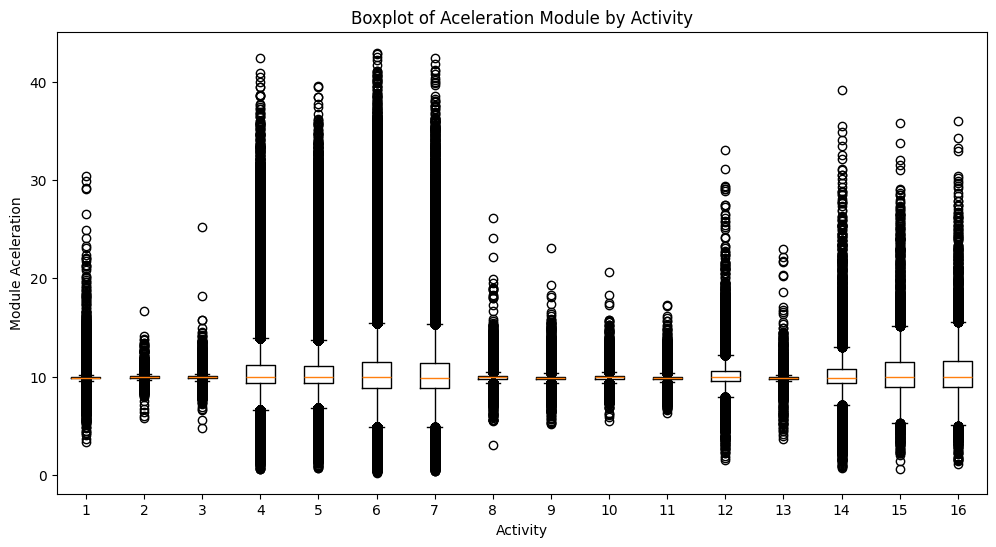

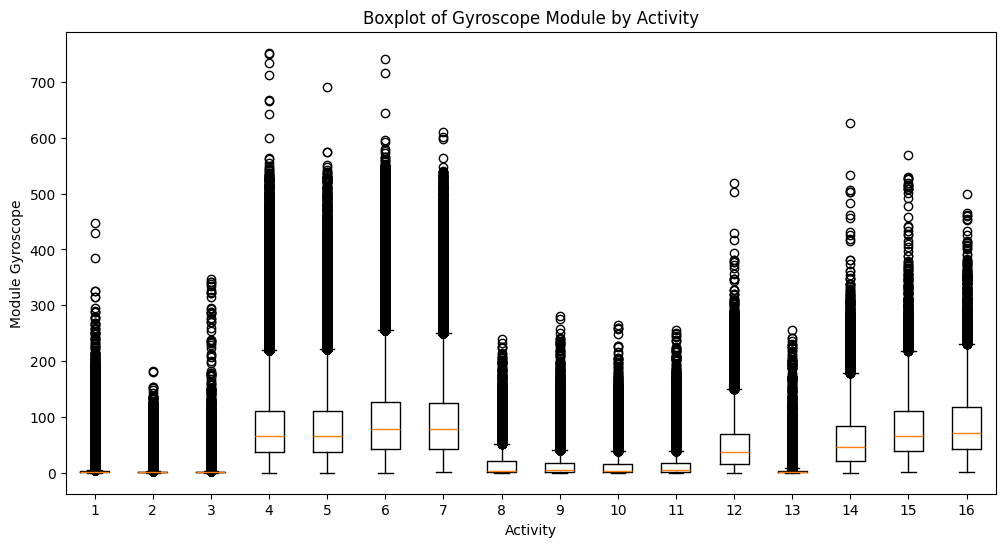

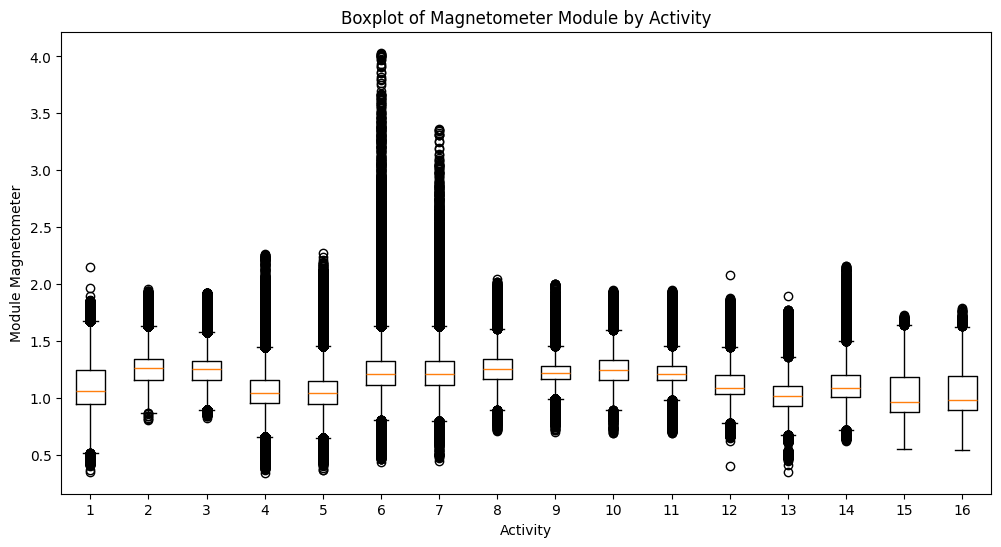

In [26]:
module_boxplots(data, 1)
module_boxplots(data, 2)
module_boxplots(data, 3)

  ## Observações:
  ### Geral:
  Existe uma grande presença de outliers em todos os sensores, o que é visível em praticamente todas as atividades. Sugere que os movimentos humanos contêm variações extremas? É necessário aprofundar a análise para perceber se estes outliers são de facto variações extremas ou se são erros de medição.
  ### Aceleração:
  #### Módulo Aceleração:
  - As atividades estáticas (1, 2, 3) apresentam uma mediana próxima de 10, que correspondem, aproximadamente, à aceleração da gravidade (~9.81 m/s²), com uma variabilidade muito reduzida(caixas pequenas). Isto indica que o corpo está maioritariamente em repouso.
  - As atividades dinâmicas (4,5,6,7) apresentam maior dispersão. Isto reflete a constante variação de aceleração inerente a estas atividades.
  #### Conclusão:
  - Os resultados são os esperados. O módulo da aceleração parece ser uma característica útil para distinguir entre atividades estáticas e dinâmicas.
  ### Giroscópio:
  #### Módulo Giroscópio:
  - Nas atividades estáticas, a mediana está praticamente a zero e a caixa é quase inexistente, indicando pouca ou nenhuma rotação. Sem movimento, não existe velocidade angular.
  - Nas atividades dinâmicas os valores de módulo e a dispersão são significativamente maiores, com outliers evidentes.
  #### Conclusão:
  - O giroscópio apresenta a distanção mais clara entre os dois tipos de atividade.
  ### Magnetómetro:
  #### Módulo Magnetómetro:
  - Existe uma enorme quantidade de outliers nas atividades 6 (Climb Stair) e 7 (Climb Stair and talk). Esse fenómeno provavelmente não se deve ao movimento em si, mas sim ao facto de escadas conterem frequentemente estruturas metálicas (corrimões, vigas, etc.) que podem interferir com o sensor magnético.
  - As atividades estáticas apresentam uma mediana
  #### Conclusão:
  - Ao contrário dos outros sensores, o magnetómetro não mostra uma distinção tão óbvia entre a maioria das atividades estáticas e dinâmicas. As medianas e os intervalos interquartis são relativamente semelhantes entre muitas das atividades. Mas em contrapartida, o magnetómetro pode ser um indicador de uma atividade relacionada com escadas, devido à quantidade de outliers observados.

### Exercício 3.2
Analise e comente a densidade de outliers existentes no dataset transformado, isto é, nos módulos dos vetores aceleração, giroscópio e magnetómetro para cada atividade (use somente os sensores do pulso direito). Observe que a densidade é determinada recorrendo:
$$ d = \frac{no}{nr} * 100 $$
em que no é o número de pontos classificados como outliers e nr é o número total de pontos.

In [ ]:
def outliers_density(data, sensor):
    #Only remove data from device id 2
    # dr = (number of outliers / total number of samples) * 100
    device_id = 2
    device_data = data[data[:,1] == device_id]
    total_num_samples = device_data.shape[0]
    
    #acel
    if sensor == 1:
        c = (2,3,4)
        label = 'Aceleration'
    # giro
    elif sensor == 2:
        c = (5,6,7)
        label = 'Gyroscope'
    #magn
    elif sensor == 3:
        c = (8,9,10)
        label = 'Magnetometer'
    else:
        raise ValueError("sensor must be 0, 1, or 2")
    # UTILIZAR TUKEY RULE PARA DETEÇÃO DE OUTLIERS (OU SEJA, VERIFICAR SE ESTÃO FORA DOS LIMITES)
    
    
    sensor_data= device_data[:, c]
    magnitude= np.linalg.norm(sensor_data, axis=1)
    
    activities= device_data[:,11]
    unique= np.unique(activities)
    results= {}
    
    for a in unique: 
        mag = magnitude[activities==a]
    
        
        Q1= np.percentile (mag, 25)
        Q3= np.percentile (mag, 75)
        IQR= Q3-Q1
        lower_limit= Q1-1.5*IQR
        upper_limit= Q3+1.5*IQR
        
        outliers = (mag < lower_limit) | (mag > upper_limit)
        
        nr= len(mag)
        no= np.sum(outliers)
        
        if nr > 0:
            density = (no / nr) * 100
        else:
            density = 0
        
        results[a] = {
            'density': density,
            'total_points': nr,
            'outliers_count': no
        }
    
    return results, label

    

### Exercício 3.3
Escreva uma rotina que receba um Array de amostras de uma variável e identifique os outliers usando o teste Z-Score para um k variável (parâmetro de entrada).

In [5]:
def detect_outliers_zscore (samples, k):
    mean= np.mean(samples)
    std= np.std(samples)
    
    z_scores = np.abs((samples - mean) / std)
    
    outliers= z_scores>k
    
    return outliers
    
#exemplo
acc_sample= np.sqrt(data[:, 2]**2 + data[:, 3]**2 + data[:, 4]**2)
acc_outliers = detect_outliers_zscore(acc_sample, k=3)
print (acc_outliers) #quando sai true é outlier


[False False False ... False False False]


### Exercício 3.4
Usando o Z-score implementado, assinale todos as amostras consideradas outliers nos módulos dos vetores de aceleração, giroscópio e magnetómetro.
Apresente plots em que estes pontos surgem a vermelho, enquanto os restantes surgem a azul. Use k=3, 3.5 e 4.

In [6]:
def plot_zscore_outliers (data, sensor, k_values=[3.0,3.5,4.0]):
    if sensor == 1:  
        c = (2, 3, 4)
        label = 'Acceleration'
    elif sensor == 2: 
        c = (5, 6, 7)
        label = 'Gyroscope'
    elif sensor == 3:  
        c = (8, 9, 10)
        label = 'Magnetometer'
        
    mod = np.sqrt((data[:,c]**2).sum(axis=1))
    all = data[:,12]
    unique_activities = np.unique(all).astype(int)
    
    
    for k in k_values:
        plt.figure()
        dados=[]
        outliers= []
        for i, activities in enumerate(unique_activities):
            mod_activity = mod[all == activities]
            if len(mod_activity)>0:
                out = detect_outliers_zscore(mod_activity, k)
                out= np.array(out)
                normais = []
                for j in range(len(mod_activity)):
                    if not out[j].item():
                        normais.append(mod_activity[j])
                dados.append(normais)
                
                for j in range(len(mod_activity)):
                    if out[j]:
                        outliers.append((i + 1, mod_activity[j]))
        
        plt.boxplot(dados)
        if outliers:
            positions = []
            values = []
            for pos, val in outliers:
                positions.append(pos)
                values.append(val)
            plt.scatter(positions, values, color='red', label=f'Outliers (k={k})')

        
        plt.xlabel('Atividade')
        plt.ylabel('Módulo')
        plt.legend()
        plt.show()
        
    

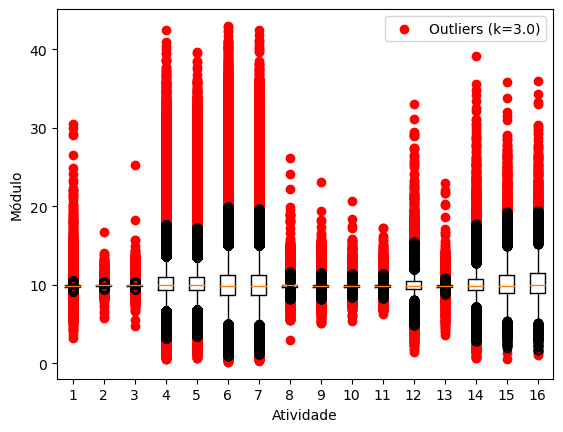

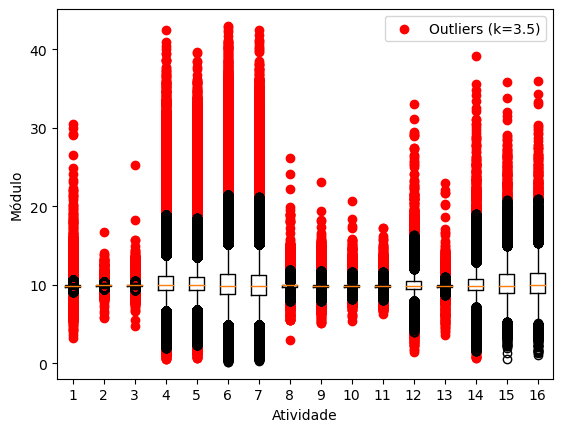

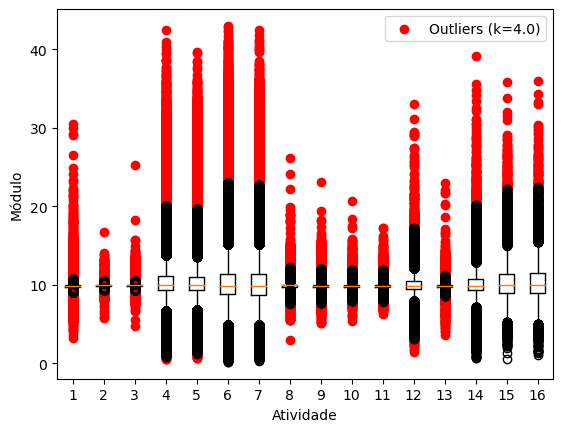

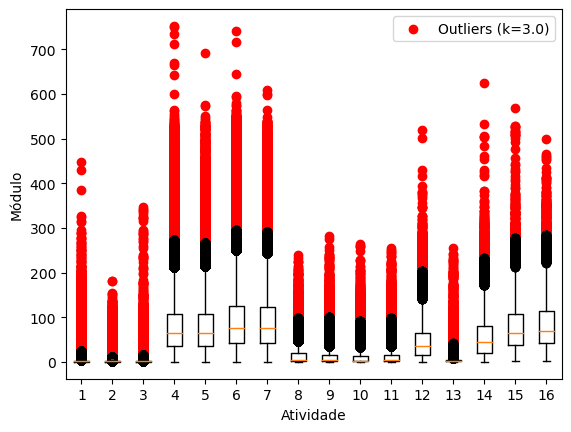

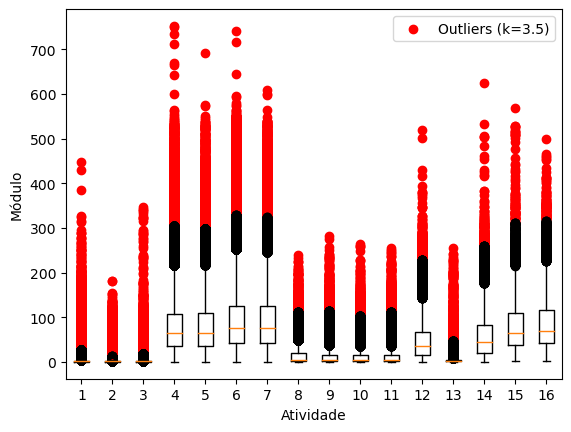

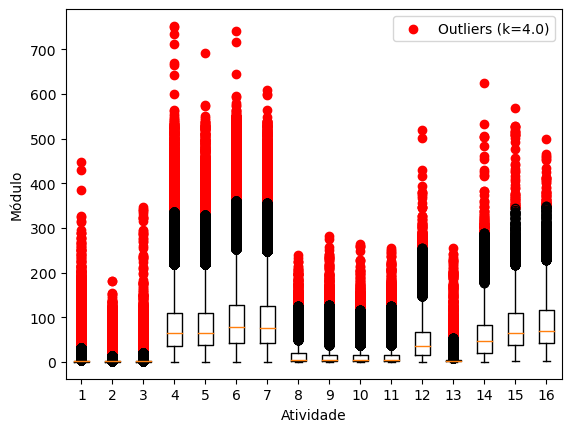

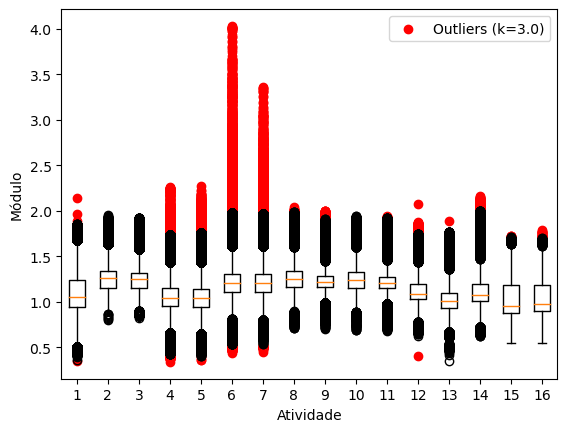

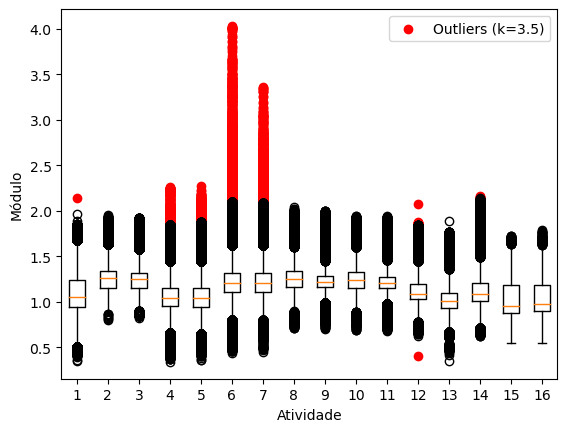

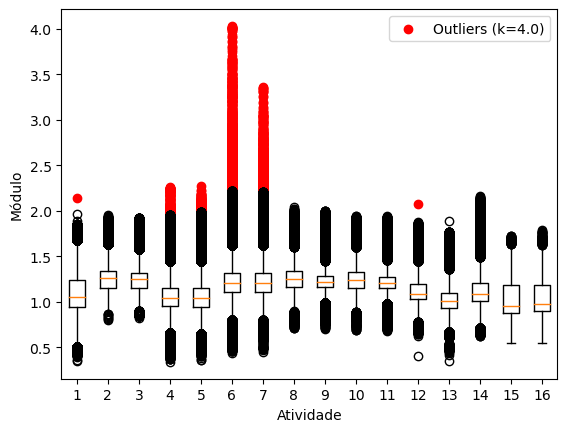

In [8]:
#fiz isto p ter a certeza q estava bem
data = load_data()
plot_zscore_outliers(data, sensor=1)  # Aceleração
plot_zscore_outliers(data, sensor=2)  # Giroscópio
plot_zscore_outliers(data, sensor=3)  # Magnetômetro

### Exercício 3.5
Compare e discuta os resultados obtidos em 3.1 e 3.4.

### Exercício 3.6
Elabore uma rotina que implemente o algoritmo k-means para n (valor de entrada) clusters.

### Exercício 3.7
Determine os outliers no dataset transformado usando o k-means.
Experimente diferentes números de clusters e compare com os resultados obtidos em 3.4. Ilustre graficamente os resultados usando gráficos 3D para cada vetor (veja, por exemplo, https://medium.com/data-science/an-easy-introduction-to-3d-plotting-with-matplotlib-801561999725).

### Exercício 3.7.1 (Bónus)
Poderá realizar um estudo análogo usando o algoritmo DBSCAN (sugere-se que recorra à [biblioteca sklearn2](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html#sklearn.cluster.DBSCAN))